# Лабораторная работа №3 Винницкая Д.С.

## Импорт библиотек и настройка

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, VBox, HBox, Layout
from IPython.display import display

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')

g = 9.81  # Ускорение свободного падения, м/с^2


## Уравнения движения

### 1. Без сопротивления воздуха (Вакуум):
Действует только сила тяжести. Траектория — **парабола**.

$$
\begin{cases}
x(t) = v_0 \cos(\alpha) \cdot t \\
y(t) = v_0 \sin(\alpha) \cdot t - \frac{gt^2}{2}
\end{cases}
$$

### 2. С сопротивлением воздуха:
Действует сила тяжести и сила сопротивления воздуха $\vec{F}_c$.
Сила сопротивления направлена против вектора скорости и пропорциональна квадрату скорости:

$$
\vec{F}_c = -k \cdot v \cdot \vec{v}
$$

где $k$ — коэффициент сопротивления, $v = |\vec{v}|$ — модуль скорости.

### Уравнения Ньютона (2-й закон):
$$
m \vec{a} = m\vec{g} + \vec{F}_c
$$

В проекциях на оси:
$$
\begin{cases}
m \frac{dv_x}{dt} = -k \cdot v \cdot v_x \\
m \frac{dv_y}{dt} = -mg - k \cdot v \cdot v_y
\end{cases}
$$

## Класс моделирования (Метод Эйлера)

In [2]:
class ProjectileMotion:
    """
    Класс для моделирования движения снаряда с учётом сопротивления воздуха.
    Использует метод Эйлера для численного интегрирования.
    """
    
    def __init__(self, v0, angle_deg, mass, k_drag, dt=0.01):
        """
        Инициализация параметров
        v0: начальная скорость (м/с)
        angle_deg: угол броска (градусы)
        mass: масса тела (кг)
        k_drag: коэффициент сопротивления воздуха (кг/м)
        dt: шаг времени (с)
        """
        self.v0 = v0
        self.angle = np.radians(angle_deg)  # Перевод в радианы
        self.mass = mass
        self.k = k_drag
        self.dt = dt
        
        # Начальные условия
        self.vx = v0 * np.cos(self.angle)
        self.vy = v0 * np.sin(self.angle)
        self.x = 0.0
        self.y = 0.0
        
        # История траектории
        self.trajectory_x = [0.0]
        self.trajectory_y = [0.0]
        self.time_history = [0.0]
        
    def step(self):
        """
        Один шаг метода Эйлера
        """
        v = np.sqrt(self.vx**2 + self.vy**2)
        
        # Ускорения (a = F / m)
        # Сопротивление: F_x = -k * v * vx
        ax = -(self.k / self.mass) * v * self.vx
        ay = -g - (self.k / self.mass) * v * self.vy
        
        # Обновление скоростей
        self.vx += ax * self.dt
        self.vy += ay * self.dt
        
        # Обновление координат
        self.x += self.vx * self.dt
        self.y += self.vy * self.dt
        
        # Запись в историю
        self.trajectory_x.append(self.x)
        self.trajectory_y.append(self.y)
        self.time_history.append(self.time_history[-1] + self.dt)
        
        # Проверка попадания в землю
        return self.y >= 0
    
    def simulate(self):
        """
        Запуск полной симуляции до падения на землю
        """
        # Сброс траектории
        self.trajectory_x = [0.0]
        self.trajectory_y = [0.0]
        self.time_history = [0.0]
        
        # Сброс начальных условий
        self.vx = self.v0 * np.cos(self.angle)
        self.vy = self.v0 * np.sin(self.angle)
        self.x = 0.0
        self.y = 0.0
        
        # Цикл симуляции
        while self.step():
            pass
            
        return np.array(self.trajectory_x), np.array(self.trajectory_y)
    
    def get_max_height(self):
        """Максимальная высота"""
        return max(self.trajectory_y)
    
    def get_range(self):
        """Дальность полёта"""
        return self.trajectory_x[-1]



## Метод Эйлера для численного интегрирования

### Принцип работы:
Метод Эйлера — простейший численный метод решения обыкновенных дифференциальных уравнений (ОДУ).

### Идея:
Заменяем производную конечной разностью:
$$
\frac{dy}{dt} \approx \frac{y(t + \Delta t) - y(t)}{\Delta t}
$$

Отсюда формула обновления:
$$
y_{new} = y_{old} + f(t, y) \cdot \Delta t
$$

### Для нашей задачи:
| Параметр | Формула обновления |
|----------|-------------------|
| Скорость $v_x$ | $v_x^{new} = v_x^{old} + a_x \cdot dt$ |
| Скорость $v_y$ | $v_y^{new} = v_y^{old} + a_y \cdot dt$ |
| Координата $x$ | $x^{new} = x^{old} + v_x \cdot dt$ |
| Координата $y$ | $y^{new} = y^{old} + v_y \cdot dt$ |

>  **Погрешность:** Метод Эйлера имеет погрешность $O(\Delta t)$. Чем меньше шаг $dt$, тем точнее результат, но дольше расчёт.

## Интерактивная визуализация

In [ ]:


def plot_trajectories(v0=50, angle=45, mass=1.0, k_drag=0.01):
    """
    Построение траекторий с сопротивлением и без
    """
    # 1. Траектория с сопротивлением (Численная)
    sim_drag = ProjectileMotion(v0, angle, mass, k_drag, dt=0.01)
    x_drag, y_drag = sim_drag.simulate()
    
    # 2. Траектория без сопротивления (Аналитическая для идеала)
    angle_rad = np.radians(angle)
    vx0 = v0 * np.cos(angle_rad)
    vy0 = v0 * np.sin(angle_rad)
    t_total = 2 * vy0 / g  # Время полёта в вакууме
    t_vacuum = np.linspace(0, t_total, 100)
    x_vacuum = vx0 * t_vacuum
    y_vacuum = vy0 * t_vacuum - 0.5 * g * t_vacuum**2
    
    # Построение графика
    plt.figure(figsize=(12, 7))
    
    # Вакуум
    plt.plot(x_vacuum, y_vacuum, 'b--', linewidth=2, label='Без сопротивления (Вакуум)', alpha=0.7)
    
    # С сопротивлением
    plt.plot(x_drag, y_drag, 'r-', linewidth=2, label=f'С сопротивлением (k={k_drag})', alpha=0.9)
    

    plt.title(f'Tраектория снаряда\n$v_0$={v0} м/с, угол={angle}°, масса={mass} кг', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Дальность X (м)', fontsize=12)
    plt.ylabel('Высота Y (м)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.axhline(0, color='black', linewidth=1)  # Земля
    
    # Статистика
    stats_text = (f"Дальность (воздух): {sim_drag.get_range():.1f} м\n"
                  f"Дальность (вакуум): {x_vacuum[-1]:.1f} м\n"
                  f"Потеря дальности: {(1 - sim_drag.get_range()/x_vacuum[-1])*100:.1f}%")
    
    plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

print("Панелька")
interact(plot_trajectories,
         v0=FloatSlider(value=50, min=10, max=100, step=5, description='v0 (м/с):', 
                       style={'description_width': 'initial'}, layout=Layout(width='400px')),
         angle=FloatSlider(value=45, min=0, max=90, step=5, description='Угол (град):', 
                          style={'description_width': 'initial'}, layout=Layout(width='400px')),
         mass=FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1, description='Масса (кг):', 
                         style={'description_width': 'initial'}, layout=Layout(width='400px')),
         k_drag=FloatSlider(value=0.01, min=0.0, max=0.1, step=0.005, description='k (сопр.):', 
                           style={'description_width': 'initial'}, layout=Layout(width='400px')));

Панелька


interactive(children=(FloatSlider(value=50.0, description='v0 (м/с):', layout=Layout(width='400px'), min=10.0,…

## Анализ зависимости дальности от угла

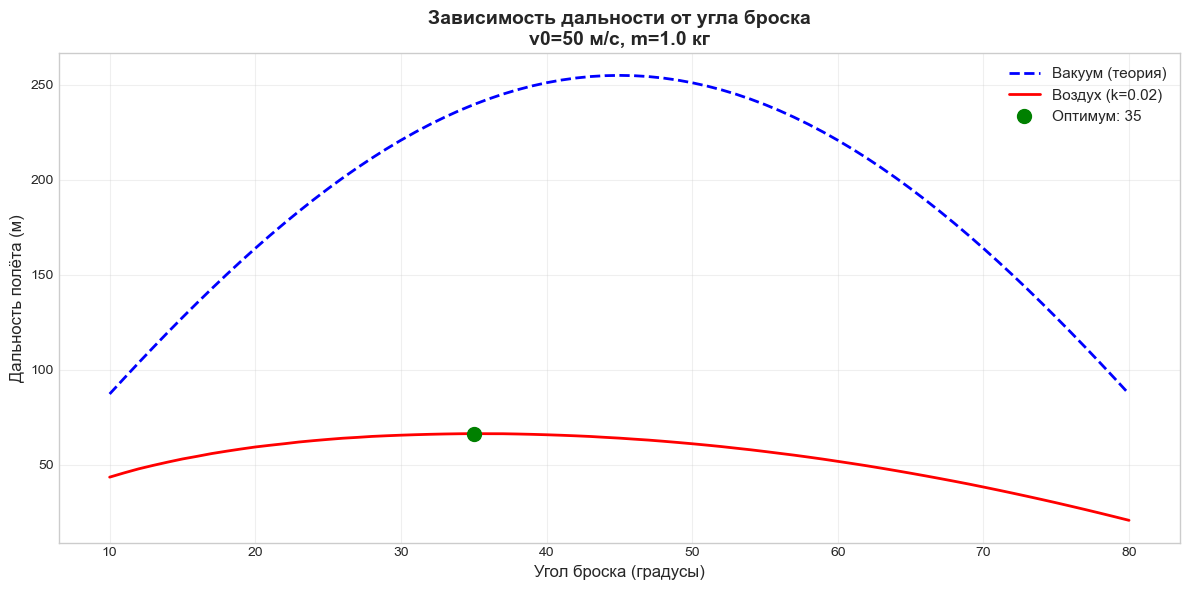

Оптимальный угол для максимальной дальности: 35
Максимальная дальность: 66.3 м


In [4]:
def analyze_range_vs_angle(k_drag=0.02, mass=1.0, v0=50):
    """
    Построение графика зависимости дальности от угла броска
    """
    angles = np.arange(10, 81, 1)
    ranges_vacuum = []
    ranges_drag = []
    
    for angle in angles:
        # Вакуум 
        rad = np.radians(angle)
        R_vac = (v0**2 * np.sin(2*rad)) / g
        ranges_vacuum.append(R_vac)
        
        # Воздух 
        sim = ProjectileMotion(v0, angle, mass, k_drag, dt=0.01)
        sim.simulate()
        ranges_drag.append(sim.get_range())
    
    # График
    plt.figure(figsize=(12, 6))
    plt.plot(angles, ranges_vacuum, 'b--', linewidth=2, label='Вакуум (теория)')
    plt.plot(angles, ranges_drag, 'r-', linewidth=2, label=f'Воздух (k={k_drag})')
    
    # Поиск максимума
    max_idx = np.argmax(ranges_drag)
    opt_angle = angles[max_idx]
    max_range = ranges_drag[max_idx]
    
    plt.plot(opt_angle, max_range, 'go', markersize=10, label=f'Оптимум: {opt_angle}')
    
    plt.title(f'Зависимость дальности от угла броска\nv0={v0} м/с, m={mass} кг', fontsize=14, fontweight='bold')
    plt.xlabel('Угол броска (градусы)', fontsize=12)
    plt.ylabel('Дальность полёта (м)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Оптимальный угол для максимальной дальности: {opt_angle}")
    print(f"Максимальная дальность: {max_range:.1f} м")


analyze_range_vs_angle()

# Ответы на контрольные вопросы

### 1. Уравнения движения с сопротивлением воздуха
Выводятся из **2-го закона Ньютона** ($\vec{F} = m\vec{a}$):
$$
m\frac{d\vec{v}}{dt} = m\vec{g} - k \cdot v \cdot \vec{v}
$$
В проекциях:
$$
\begin{cases}
\dot{v}_x = -\frac{k}{m} v v_x \\
\dot{v}_y = -g - \frac{k}{m} v v_y
\end{cases}
$$

### 2. Зависимость силы сопротивления от скорости
$$F_c \propto v^2$$
**Почему квадратичная?** При больших скоростях (число Рейнольдса $Re > 1000$) обтекание становится турбулентным. Сила сопротивления определяется давлением набегающего потока ($P \sim \rho v^2$), поэтому $F \sim v^2$.

### 3. Почему траектория не парабола?
Парабола возможна только при постоянном ускорении ($\vec{a} = const$).
С сопротивлением воздуха сила (и ускорение) **зависит от скорости**, которая меняется в течение полёта.
**Изменения:**
- Нисходящая ветвь круче восходящей
- Дальность полёта меньше
- Угол падения больше угла броска

### 4. Почему для снарядов учитывают вращение Земли?
Для дальнобойной артиллерии (десятки км) проявляется **сила Кориолиса**.
За время полёта Земля поворачивается, что вызывает отклонение снаряда в сторону (вправо в Сев. полушарии). Без учёта промах может составить сотни метров.

### 5. Принцип метода Эйлера
Аппроксимация производной разностным отношением.
Касательная к решению в точке $t$ продолжается на шаг $\Delta t$.
$$y_{i+1} = y_i + f(t_i, y_i) \cdot \Delta t$$
Это линейная экстраполяция на малом отрезке.

### 6. Разностные уравнения для нашей системы
$$
\begin{cases}
v_{x, i+1} = v_{x, i} - \frac{k}{m} v_i v_{x, i} \cdot \Delta t \\
v_{y, i+1} = v_{y, i} - (g + \frac{k}{m} v_i v_{y, i}) \cdot \Delta t \\
x_{i+1} = x_i + v_{x, i} \cdot \Delta t \\
y_{i+1} = y_i + v_{y, i} \cdot \Delta t
\end{cases}
$$
где $v_i = \sqrt{v_{x,i}^2 + v_{y,i}^2}$.

## Выводы по лабораторной работе

1. **Сопротивление воздуха существенно влияет** на траекторию: уменьшает дальность и высоту полёта.
2. **Форма траектории искажается:** становится несимметричной, нисходящая ветвь более крутая.
3. **Оптимальный угол броска** с сопротивлением воздуха **меньше 45°** (обычно 35–40°).
4. **Масса тела важна:** чем больше масса (при том же $k$), тем меньше влияние сопротивления (большая инерция).
5. **Метод Эйлера** позволяет решать сложные дифференциальные уравнения, не имеющие аналитического решения, но требует малого шага $\Delta t$ для точности.

### Практическое значение:
- Баллистические расчёты в артиллерии
- Проектирование спортивных снарядов
- Аэродинамика летательных аппаратов